# Digital Signal Processing Training Program 

![Texto Alternativo](images/V-CC_Color_Completa_TextoAzul.png)

### Dev by:
-   Elmer Pimentel Farias


# Analog-to-Digital and Digital-to-Analog Conversors

## Introduction

In modern electronic systems, Analog-to-Digital Converters (ADCs) and Digital-to-Analog Converters (DACs) serve as the essential interface between the analog physical world and digital signal processing systems. This notebook explores the critical stages of this conversion process: **Sampling**, **Holding**, **Quantization**, and **Encoding**.

The conversion process begins with sampling, where a continuous signal is measured periodically to create discrete values in time. Following this, quantization maps these continuous amplitude values to a finite set of $L = 2^N$ levels, where $N$ is the number of bits. This process introduces an inherent quantization error ($n_q$), which can be modeled as uniform noise.

### 1. Quantization Step ($\Delta$)

The resolution of the quantizer, or the distance between two adjacent levels, is determined by the dynamic range and the number of bits ($N$):

$$\Delta = \frac{V_{max} - V_{min}}{2^N}$$


### 2. Quantization Noise Power ($P_q$)

Under the assumption that the error is uniformly distributed between $[-\frac{\Delta}{2}, \frac{\Delta}{2}]$, the average power of the quantization noise is given by its variance:

$$P_q = \sigma_{n_q}^2 = \frac{\Delta^2}{12}$$

### 3. Ideal Signal-to-Quantization-Noise Ratio (SQNR)

For an ideal $N$-bit ADC excited by a full-scale sine wave, the SQNR in decibels is expressed as:

$$SQNR_{ideal} = 6.02N + 1.76 \text{ [dB]}$$


* The 6,02 term represents the 6 dB gain in SNR for every additional bit.


* The 1,72 term is associated with the RMS power of a sinusoid.



### 4. Effective Number of Bits (ENOB)

In real-world scenarios where distortion and non-ideal noise are present, we measure the $SNR_{real}$ to calculate the effective resolution of the converter:


$$ENOB = \frac{SNR_{real} - 1.76}{6.02}$$


## Project Objectives

We will develop a Python environment to:

* **Simulate Sampling and Reconstruction:** Model the sampling of a square wave and its reconstruction via Zero-Order Hold (ZOH).


* **Implement Uniform Quantization:** Create a function to map analog values to discrete levels and calculate the resulting error $n_q = V - V_q$ .


* **Calculate SNR and ENOB:** Compute the power of the original signal versus the noise to evaluate if our simulated ADC meets its theoretical bit depth.


* **Spectral Analysis:** Use Fast Fourier Transforms (FFT) to generate spectrum graphs and identify the harmonic distortions introduced by quantization.



### 1- Imports

In [228]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz
from scipy import signal
from numba import njit
from scipy.linalg import toeplitz, inv
import pandas as pd
import numpy as np
import time
from scipy.signal import periodogram
from scipy.signal import butter, filtfilt, square
from scipy.fft import fft, fftfreq


### 1. Signal and Time Preparation

* **Time Axis Reconstruction**: The function first recreates the time axis of the continuous signal based on its length and its original analog frequency (`fs_analog`).
* **Noise Injection**: It optionally adds Additive White Gaussian Noise (AWGN) to simulate real-world thermal interference or imperfections before the conversion process begins.

### 2. Sampling (Amostragem)

* **Periodic Measurement**: The continuous analog signal is measured periodically, producing discrete values in time according to a specified sampling rate.


* **Downsampling**: The code calculates a `step` ratio between the original analog frequency (`fs_analog`) and the desired ADC sampling rate (`fs_sample`) to extract the precise discrete samples from the input array.

### 3. Quantization (Quantização)

This step ensures the continuous amplitude values of the sampled signal are represented by a finite set of predefined levels.

* **Number of Levels ($L$)**: The total number of quantization levels is calculated as $L = 2^N$, where $N$ represents the number of bits of the ADC.


* **Quantization Step ($\Delta$)**: The code calculates the quantization step, which is the uniform distance between each level. The formula used is $\Delta = \frac{V_{max} - V_{min}}{2^N}$.


* **Index Mapping & Overload Prevention**: The sampled voltage is divided by the step $\Delta$ to find its corresponding integer index $k$. To prevent signal overload or saturation, the code clips this index so it does not exceed the maximum physical limits of the ADC.


* **Reconstruction Level ($V_q$)**: The function uses a mid-rise uniform quantizer to calculate the final quantized voltage level for each sample. The mathematical formula applied is $V_q(k) = V_{min} + (k + \frac{1}{2})\Delta$.



### 4. Quantization Noise (Erro de quantização)

* **Error Calculation**: The code calculates the quantization error, which is defined as the difference between the actual sampled input and the quantized output: $n_q = V - V_q$.


* **Inherent Flaw**: This error is inherent to the quantization process and acts as a form of noise added to the digital signal.



### 5. Encoding (Codificação)

* **Binary Mapping**: The quantized levels (represented by the integer index $k$) are then mapped to binary codes.


* **Formatting**: The code converts the indices into binary strings, padding them with leading zeros to ensure every output string exactly matches the specified number of `bits` (e.g., a 3-bit ADC will output '000' for $k=0$ and '111' for $k=7$).



### 6. SNR and ENOB Calculation

* **Power Calculation**: The function computes the average power (mean square) of both the sampled signal ($P_{signal}$) and the quantization noise ($P_{noise}$).
* **Signal-to-Noise Ratio (SNR)**: It calculates the actual Signal-to-Noise Ratio ($SNR_{real}$) in decibels.


* **Effective Number of Bits (ENOB)**: Finally, it calculates the ENOB, a metric that expresses the effective resolution of the ADC by taking into account all sources of noise and distortion present in the real device. The mathematical definition of ENOB used in the code is $ENOB = \frac{SNR_{real} - 1.76}{6.02}$.

In [ ]:
def adc_simulation(x_analog, fs_analog, fs_sample, bits, v_min, v_max, noise_std=0.0):
    """
    Simulates a complete Analog-to-Digital Converter (ADC), including noise, 
    sampling, quantization, and encoding (binary output).
    
    Parameters:
    x_analog  : Array of the input analog signal.
    fs_analog : Original sampling frequency of the "analog" signal (in Hz).
    fs_sample : Sampling rate of the ADC (in Hz).
    bits      : ADC resolution in number of bits (N).
    v_min     : Minimum voltage of the input dynamic range (in Volts).
    v_max     : Maximum voltage of the input dynamic range (in Volts).
    noise_std : Standard deviation of the Gaussian noise added to the signal.
    
    Returns:
    t_sampled          : Time axis of the samples.
    x_sampled          : Exact values of the samples.
    x_quantized        : Quantized values (voltage levels).
    quantization_noise : The error introduced by quantization.
    binary_output      : List of binary strings representing the digital output.
    """
    
    # 1. SIGNAL AND TIME PREPARATION
    
    # We recreate the time axis of the continuous signal based on its length
    # and its original generation frequency.
    num_samples = len(x_analog)
    t_final = (num_samples - 1) / fs_analog
    t_analog = np.linspace(0, t_final, num_samples)
    #t_analog = np.arange(len(x_analog)) / fs_analog
    
    # Additive White Gaussian Noise (AWGN) Injection
    # Simulates thermal imperfections or real-world interference in the input signal.
    
    if noise_std > 0:
        noise = np.random.normal(0, noise_std, len(x_analog))
        x_noisy = x_analog + noise
    else:
        x_noisy = x_analog
        
    # 2. SAMPLING
    # The continuous analog signal is measured periodically.
    # We calculate the required "step" in the array to extract samples 
    # exactly at the desired fs_sample frequency.

    step = max(1, int(fs_analog / fs_sample))
    t_sampled = t_analog[::step]
    x_sampled = x_noisy[::step]
    x_analog_amostrado = x_analog[::step]  # Sinal original amostrado para comparação
    # 3. QUANTIZE
    # The continuous amplitude values are represented by a finite set of predefined levels
    
    # Total number of quantization levels (L = 2^N)[cite: 64].
    L = 2**bits 

    # Quantization step (Delta), which is the distance between each level[cite: 67].
    # Formula: Delta = (V_max - V_min) / 2^N[cite: 138].

    delta = (v_max - v_min) / L 
    
    # Mapping the sample value to the corresponding level index 'k'.
    # We use np.floor to find which "step" the sample fits into.

    k = np.floor((x_sampled - v_min) / delta)

    # Overload (Saturation) Prevention.
    # We ensure that the index 'k' does not exceed the physical limits of the ADC (0 to L-1).

    k = np.clip(k, 0, L - 1) 
    
    # Calculation of the reconstruction level (V_q) for a mid-rise uniform quantizer.
    # The exact formula is V_q(k) = V_min + (k + 0.5) * Delta

    x_quantized = v_min + (k + 0.5) * delta
    
    # 4. QUANTIZATION NOISE
    quantization_noise = x_sampled - x_quantized
    
    # 5. ENCODE (BINARY OUTPUT)
    # The quantized levels are mapped to binary codes.
    # We convert the index 'k' (float array) to integers.
    k_int = k.astype(int)
    
    # Format each integer into a binary string padded with zeros to match 'bits' length.
    # E.g., for bits=3: k=0 -> '000', k=7 -> '111'.
    binary_output = [format(val, f'0{bits}b') for val in k_int]
    gray_output = [format(val ^ (val >> 1), f'0{bits}b') for val in k_int]

    # 6. SNR AND ENOB CALCULATION
   # Calculate the average power (mean square) of the sampled signal and the quantization noise
    P_signal = np.mean(x_analog_amostrado**2)  ##(x_sampled**2)
    P_noise = np.mean(quantization_noise**2)
    
    # Prevents division by zero if the noise is perfectly zero (extreme theoretical scenario)
    if P_noise == 0:
        snr_db = float('inf')
        enob = float('inf')
    else:
        # Actual Signal-to-Noise Ratio (SNR) in dB
        snr_db = 10 * np.log10(P_signal / P_noise)
        
        # Effective Number of Bits (ENOB) calculation
        # Formula: ENOB = (SNR_real - 1.76) / 6.02 (As defined in the course material)
        enob = (snr_db - 1.76) / 6.02
        
    return t_sampled, x_sampled, x_quantized, quantization_noise, binary_output, gray_output,snr_db, enob

Mean results over 10 executions with noise:
-----------------------------------
ADC Resolution (3 bits) - Mean of 10 runs
SNR Real: 17.51 dB
ENOB Calculate: 2.62 bits
-----------------------------------
|   Time [s] |   Real Sample [V] |   Quantized [V] |   Quantization Noise [V] |   Binary Code |
|-----------:|------------------:|----------------:|-------------------------:|--------------:|
|      0     |          0.977648 |           0.875 |                0.102648  |           111 |
|      0.001 |          0.964626 |           0.875 |                0.0896263 |           111 |
|      0.002 |          1.08684  |           0.875 |                0.211845  |           111 |
|      0.003 |          0.988573 |           0.875 |                0.113573  |           111 |
|      0.004 |          1.01721  |           0.875 |                0.142212  |           111 |
|      0.005 |          0.989966 |           0.875 |                0.114966  |           111 |
|      0.006 |          1.044

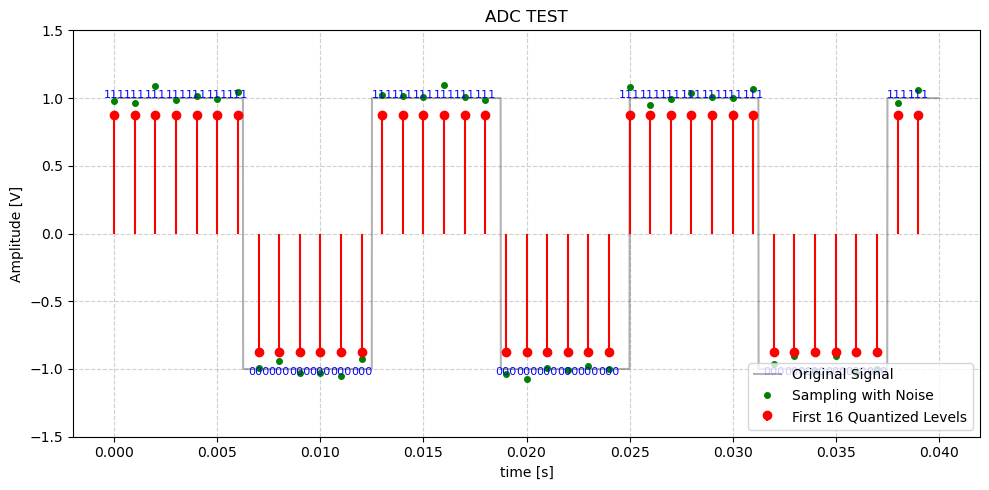

In [168]:
fs_analog_test = 100000 
f_signal_test = 80 # 50 Hz square wave
t_temp = np.linspace(0, 0.04, int(fs_analog_test * 0.04)) # 40 ms duration

#x_analog_test =  np.cos(2 * np.pi * f_signal_test * t_temp) # This will create a cosine wave
x_analog_test = signal.square(2 * np.pi * f_signal_test * t_temp)

# ADC parameters
fs_sample_test = 1000 # 1 kHz sampling rate
bits_test = 3         # 3-bit resolution
v_min_test = -1.0
v_max_test = 1.0
num_execucoes = 10
snr_resultados = []
enob_resultados = []
noise_std_test = 0.05 # Standard deviation of the noise to be added

print(f"Mean results over {num_execucoes} executions with noise:")

for i in range(num_execucoes):
    _, _, _, _, _, gray_output, snr_run, enob_run = adc_simulation(
        x_analog=x_analog_test, 
        fs_analog=fs_analog_test, 
        fs_sample=fs_sample_test, 
        bits=bits_test, 
        v_min=v_min_test, 
        v_max=v_max_test,
        noise_std=noise_std_test #Noise
    )
    
    # Keep track of results for each run
    snr_resultados.append(snr_run)
    enob_resultados.append(enob_run)

# Finals Means
media_snr = np.mean(snr_resultados)
media_enob = np.mean(enob_resultados)


print("-" * 35)
print(f"ADC Resolution ({bits_test} bits) - Mean of {num_execucoes} runs")
print(f"SNR Real: {media_snr:.2f} dB")
print(f"ENOB Calculate: {media_enob:.2f} bits")
print("-" * 35)

# Run simulation
t_samp, x_samp, x_quant, noise, bits_out, gray_output, snr_db, enob = adc_simulation(
    x_analog=x_analog_test, 
    fs_analog=fs_analog_test, 
    fs_sample=fs_sample_test, 
    bits=bits_test, 
    v_min=v_min_test, 
    v_max=v_max_test,
    noise_std= noise_std_test # Adding a bit more noise to see the effect on the flat tops
)

# Plot to verify
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_temp, x_analog_test, 'k-', alpha=0.3, label='Original Signal')
#ax.step(t_samp, x_quant, where='post', color='r', label='Saída ADC (Quantizada)')
ax.plot(t_samp, x_samp, 'go', markersize=4, label='Sampling with Noise')
ax.stem(t_samp, x_quant, linefmt='r-', markerfmt='ro', basefmt=' ', label='First 16 Quantized Levels')

# Add text annotations for the first few binary codes
for i in range(40):
    # Adjusting text position slightly based on the signal value
    y_offset = 0.15 if x_quant[i] > 0 else -0.15
    ax.text(t_samp[i], x_quant[i] + y_offset, bits_out[i], fontsize=8, color='blue', ha='center', va='center')

ax.set_title('ADC TEST')
ax.set_xlabel('time [s]')
ax.set_ylabel('Amplitude [V]')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(-1.5, 1.5)
plt.tight_layout()
# Print tabular results
df_test = pd.DataFrame({
    'Time [s]': t_samp[:16],
    'Real Sample [V]': x_samp[:16],
    'Quantized [V]': x_quant[:16],
    'Quantization Noise [V]': noise[:16],
    'Binary Code': bits_out[:16]
})
print(df_test.to_markdown(index=False))

Evaluating the ADC for different resolutions...

Bits   | RMS Error (V)   | SNR (dB)     | ENOB
--------------------------------------------------
2      | 0.126003        | 13.04        | 1.87
3      | 0.073577        | 17.72        | 2.65
4      | 0.036392        | 23.83        | 3.67
5      | 0.017223        | 30.33        | 4.75
6      | 0.008262        | 36.71        | 5.81
7      | 0.004678        | 41.65        | 6.63
8      | 0.002204        | 48.18        | 7.71
9      | 0.001122        | 54.05        | 8.69
10     | 0.000607        | 59.38        | 9.57
11     | 0.000293        | 65.72        | 10.62
12     | 0.000140        | 72.15        | 11.69
13     | 0.000569        | 59.96        | 9.67
14     | 0.000035        | 84.07        | 13.67


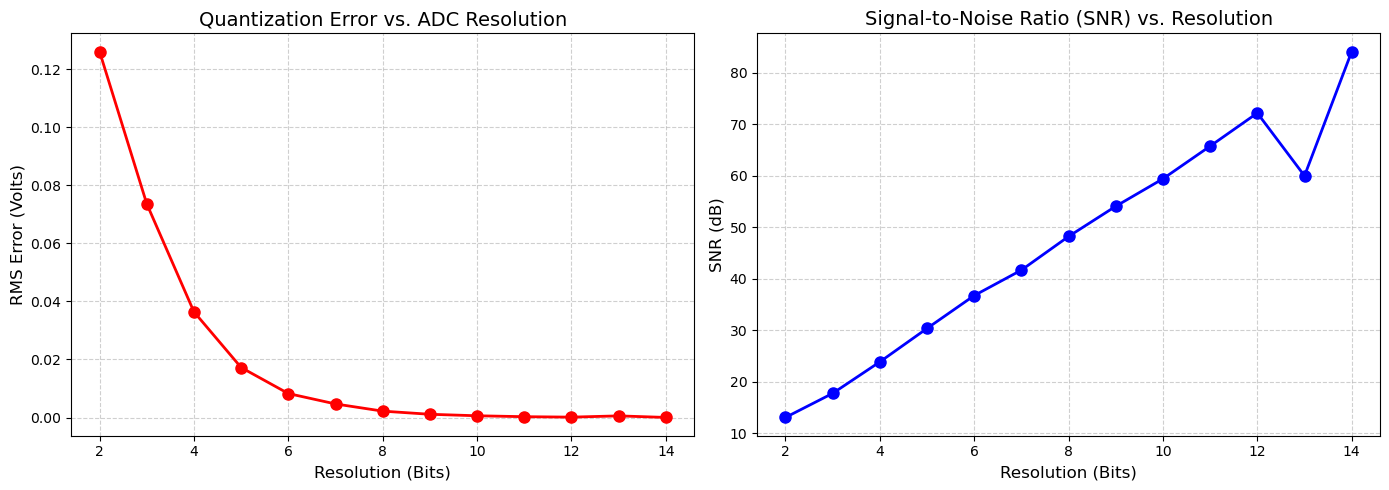

In [170]:
fs_analog_test = 100000 
f_signal_test = 100 # 100 Hz sine wave
t_temp = np.linspace(0, 0.05, int(fs_analog_test * 0.05)) 

# Full-scale sine wave for the ENOB formula to work perfectly
x_analog_test = 0.8*np.sin(2 * np.pi * f_signal_test * t_temp)

fs_sample_test = 5000 # 5 kHz
v_min_test = -1.0
v_max_test = 1.0

# List of resolutions to test (from 2 to 14 bits)
bit_levels = np.arange(2, 15)

# Lists to store the results
rms_errors = []
snr_results = []
enob_results = []

print("Evaluating the ADC for different resolutions...\n")
print(f"{'Bits':<6} | {'RMS Error (V)':<15} | {'SNR (dB)':<12} | {'ENOB'}")
print("-" * 50)

for bits in bit_levels:
    # Run the simulation for the current resolution (with no additive noise)
    t_samp, x_samp, x_quant, noise, bits_out, grey_out, snr_db, enob = adc_simulation(
        x_analog=x_analog_test, 
        fs_analog=fs_analog_test, 
        fs_sample=fs_sample_test, 
        bits=bits, 
        v_min=v_min_test, 
        v_max=v_max_test,
        noise_std=0.07 # No external noise to isolate the quantization noise
    )
    
    # Calculate the RMS Error (Square Root of the Mean Noise Power)
    erro_rms = np.sqrt(np.mean(noise**2))
    
    # Store the data
    rms_errors.append(erro_rms)
    snr_results.append(snr_db)
    enob_results.append(enob)
    
    print(f"{bits:<6} | {erro_rms:<15.6f} | {snr_db:<12.2f} | {enob:.2f}")

# --- PLOTTING THE RESULTS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Exponential Drop of the Quantization Error
ax1.plot(bit_levels, rms_errors, 'ro-', linewidth=2, markersize=8)
ax1.set_title('Quantization Error vs. ADC Resolution', fontsize=14)
ax1.set_xlabel('Resolution (Bits)', fontsize=12)
ax1.set_ylabel('RMS Error (Volts)', fontsize=12)
#ax1.set_yscale('log') # Logarithmic scale to see the exponential drop
ax1.grid(True, which="both", ls="--", alpha=0.6)

# Plot 2: SNR Increase
ax2.plot(bit_levels, snr_results, 'bo-', linewidth=2, markersize=8)
ax2.set_title('Signal-to-Noise Ratio (SNR) vs. Resolution', fontsize=14)
ax2.set_xlabel('Resolution (Bits)', fontsize=12)
ax2.set_ylabel('SNR (dB)', fontsize=12)
ax2.grid(True, ls="--", alpha=0.6)

plt.tight_layout()
plt.show()

### *Numba* in ADC
Numba Doesn't Accept Binary Strings as Output. Numba works by translating your Python code into machine code (at the C/C++ level) using a compiler called LLVM. To achieve maximum speed (using the @njit or no-python mode), Numba needs to know the exact data type and memory size of every variable ahead of time.

In [171]:
@njit
def adc_simulation(x_analog, fs_analog, fs_sample, bits, v_min, v_max, noise_std=0.0):
    """
    Simulates the sampling and quantization stages of an ADC.
    Optimized with Numba for high-performance array operations.
    Returns quantized levels as integers instead of binary strings.
    """
    
    # 1. TIME AND SIGNAL PREPARATION
    num_samples = len(x_analog)
    t_final = (num_samples - 1) / fs_analog
    t_analog = np.linspace(0.0, t_final, num_samples)
    
    # Additive White Gaussian Noise (AWGN) Injection
    if noise_std > 0.0:
        noise = np.random.normal(0.0, noise_std, num_samples)
        x_noisy = x_analog + noise
    else:
        x_noisy = x_analog
        
    # 2. SAMPLING
    # Calculate the step size to decimate the analog signal at fs_sample
    step = max(1, int(fs_analog / fs_sample))
    t_sampled = t_analog[::step]
    x_sampled = x_noisy[::step]
    
    # 3. QUANTIZATION
    # Calculate total number of levels (L) and step size (Delta)
    L = 2**bits 
    delta = (v_max - v_min) / L 
    
    # Map samples to level indices (k)
    k = np.floor((x_sampled - v_min) / delta)
    
    # Prevent overload/saturation by clipping indices to valid range [0, L-1]
    k = np.clip(k, 0, L - 1) 
    
    # Calculate reconstructed voltage levels
    x_quantized = v_min + (k + 0.5) * delta
    
    # 4. QUANTIZATION NOISE & INTEGER LEVELS
    quantization_noise = x_sampled - x_quantized
    
    # Convert indices to 64-bit integers for external encoding
    k_int = k.astype(np.int64)
    
    # 5. SNR AND ENOB CALCULATION
    # Calculate average signal power and noise power
    P_signal = np.mean(x_sampled**2)
    P_noise = np.mean(quantization_noise**2)
    
    if P_noise == 0.0:
        snr_db = np.inf
        enob = np.inf
    else:
        # Signal-to-Noise Ratio in dB
        snr_db = 10.0 * np.log10(P_signal / P_noise)
        # Effective Number of Bits
        enob = (snr_db - 1.76) / 6.02
        
    return t_sampled, x_sampled, x_quantized, quantization_noise, k_int, snr_db, enob

def encode_to_binary_strings(k_int, bits, grey):
    """
    Converts an array of integer quantization levels into zero-padded binary strings.
    This runs in standard Python, as Numba is not optimized for string manipulation.
    
    Parameters:
    k_int : Array of integer values representing quantization levels.
    bits  : ADC resolution (used to pad zeros on the left).
    
    Returns:
    List of binary strings (e.g., ['001', '010', '111']).
    List of Gray code strings (e.g., ['000', '001', '011']).
    """
    # Use native list comprehension for fast Python string formatting
    return [format(val, f'0{bits}b') for val in k_int], [format(val ^ (val >> 1), f'0{bits}b') for val in k_int]

#### Modeling ADC with a knowledge ENOB

In [172]:
def adc_dynamic_model(analog_in, enob, v_max, v_min, margin_bits=2):
    """
    Simulates an ADC, applying quantization steps and random noise 
    to match a specific Effective Number of Bits (ENOB). It also 
    returns the digital integer codes and binary string representations.
    
    Parameters:
    -----------
    analog_in : numpy.ndarray
        The input analog signal array to be converted.
    enob : float
        The target Effective Number of Bits (ENOB) for the ADC.
    v_max : float
        The maximum voltage limit of the ADC's dynamic range.
    v_min : float
        The minimum voltage limit of the ADC's dynamic range.
    margin_bits : int, optional
        Extra bits added to the ENOB to define the physical hardware resolution 
        (default is 2).
        
    Returns:
    --------
    digital_out : numpy.ndarray
        The final digital signal array (voltage level with noise).
    quant_error : numpy.ndarray
        The pure quantization error (analog_in minus ideal discrete steps).
    total_error : numpy.ndarray
        The total error introduced by the ADC (analog_in minus digital_out).
    step_size : float
        The voltage step size (Least Significant Bit - LSB) of the ADC.
    snr_db : float
        The theoretical Signal-to-Noise Ratio in dB corresponding to the target ENOB.
    num_bits : int
        The physical resolution of the ADC hardware in bits.
    digital_codes : numpy.ndarray
        Array of integer representations of the digital signal (0 to 2^num_bits - 1).
    bit_strings : list of str
        List of binary string representations of the digital codes (e.g., '1010').
    """
    # Calculate theoretical Signal-to-Noise Ratio (SNR) in dB
    snr_db = 6.02 * enob + 1.76
    
    # Calculate signal power and the required noise power for the SNR
    signal_power = np.mean(analog_in**2)
    noise_power = signal_power / (10**(snr_db / 10))
    
    # Standard deviation for the Gaussian noise
    noise_std = np.sqrt(noise_power)
    
    # Define physical resolution and the step size
    num_bits = int(np.ceil(enob)) + margin_bits
    L = 2**num_bits
    step_size = (v_max - v_min) / L
    
    # --- Stage 1: Ideal Quantization ---
    # Map the analog signal to discrete voltage steps
    quantized_signal = np.round((analog_in - v_min) / step_size) * step_size + v_min
    
    # Clip values that exceed the voltage range
    quantized_signal = np.clip(quantized_signal, v_min, v_max)
    
    # Pure quantization error (sawtooth difference)
    quant_error = analog_in - quantized_signal 
    
    # --- Stage 2: Noise Injection ---
    # Inject Gaussian noise to degrade the resolution down to the ENOB
    noise = noise_std * np.random.randn(len(analog_in))
    digital_out = quantized_signal + noise
    
    # Clip the noisy signal to ensure it doesn't exceed the ADC's physical limits
    digital_out = np.clip(digital_out, v_min, v_max)
    
    # Total error (quantization steps + random noise)
    total_error = analog_in - digital_out

    # --- Stage 3: Digital Bit Conversion ---
    # Map the voltage back to discrete index codes, ensuring they are integers
    digital_codes = np.round((digital_out - v_min) / step_size).astype(int)
    
    # Clip indices to prevent out-of-bounds errors due to added noise
    digital_codes = np.clip(digital_codes, 0, L - 1)
    
    # Format each integer into a binary string padded with zeros to match 'num_bits' length
    bit_strings = [format(val, f'0{num_bits}b') for val in digital_codes]
    #Format each integer into a Gray code string padded with zeros to match 'num_bits' length
    gray_strings = [format(val ^ (val >> 1), f'0{num_bits}b') for val in digital_codes]

    return digital_out, quant_error, total_error, step_size, snr_db, num_bits, digital_codes, bit_strings, gray_strings


Configuration: ENOB = 2 (Hardware Resolution = 4 bits, LSB = 0.1875 V)
|   Time [s] |    Analog In [V] |   Quantized [V] |        Noise/Error [V] |   Binary Code |
|------------|------------------|-----------------|------------------------|---------------|
|      0.000 |         1.000000 |        1.289016 |              -0.289016 |          1111 |
|      0.001 |         1.000000 |        1.107037 |              -0.107037 |          1110 |
|      0.002 |         1.000000 |        0.592424 |               0.407576 |          1011 |
|      0.003 |         1.000000 |        1.108490 |              -0.108490 |          1110 |
|      0.004 |         1.000000 |        0.749705 |               0.250295 |          1100 |
|      0.005 |         1.000000 |        0.910631 |               0.089369 |          1101 |
|      0.006 |        -1.000000 |       -0.952930 |              -0.047070 |          0011 |
|      0.007 |        -1.000000 |       -1.061610 |               0.061610 |          0010 

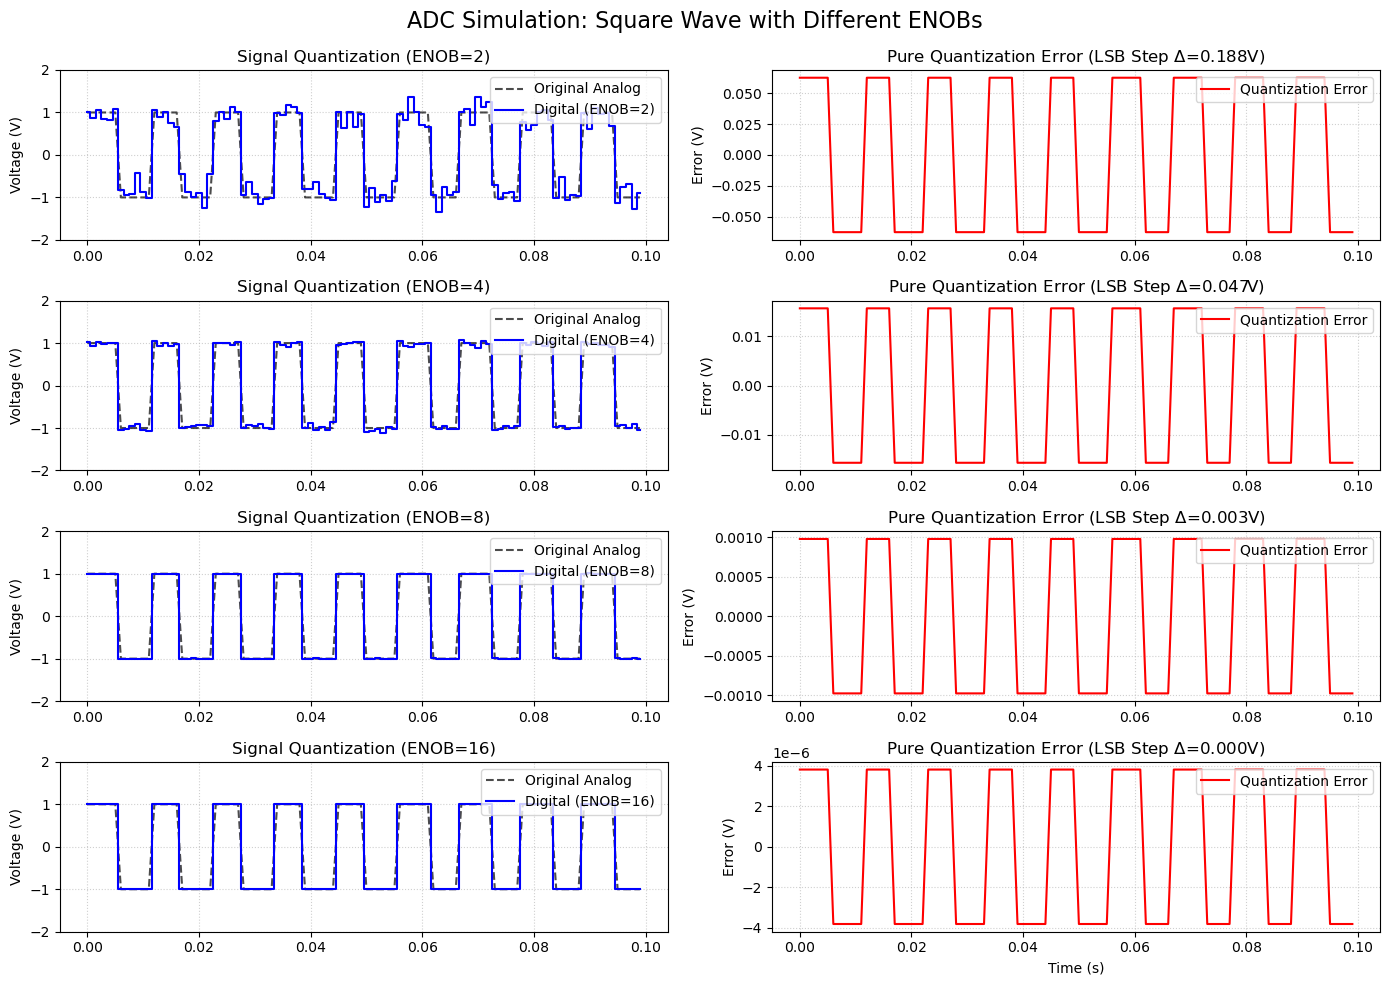

In [215]:
# --- 1. Signal Generation (Square Wave) ---
sampling_freq = 1000  # Sampling frequency in Hz
time_vector = np.arange(0, 0.1, 1/sampling_freq)  # 0.1s duration
signal_freq = 90  # 90 Hz square wave
voltage_max = 1.5
voltage_min = -1.5

# Generate a square wave with amplitude peaks at +1 and -1
analog_input = signal.square(2 * np.pi * signal_freq * time_vector)

# --- 2. Configuration ---
enob_values = [2, 4, 8, 16]
samples_to_display = 10

# --- 3. Visualization Setup ---
fig, axes = plt.subplots(len(enob_values), 2, figsize=(14, 10))
fig.suptitle('ADC Simulation: Square Wave with Different ENOBs', fontsize=16)

# Main processing loop
for i, enob in enumerate(enob_values):
    # Process the signal through the dynamic ADC model
    # Note: Assuming 'adc_dynamic_model' is defined in your environment
    (digital_out, quant_error, total_error, step_size, snr, 
     hardware_bits, quant_codes, bin_strings, gray_strings) = adc_dynamic_model(
        analog_input, enob, voltage_max, voltage_min
    )
    
    # --- Plot A: Analog vs. Digital Comparison ---
    signal_axis = axes[i, 0]
    signal_axis.plot(time_vector, analog_input, 'k--', alpha=0.7, label='Original Analog')
    signal_axis.step(time_vector, digital_out, 'b-', where='mid', label=f'Digital (ENOB={enob})')
    signal_axis.set_title(f'Signal Quantization (ENOB={enob})')
    signal_axis.set_ylabel('Voltage (V)')
    signal_axis.grid(True, linestyle=':', alpha=0.6)
    signal_axis.legend(loc='upper right')
    signal_axis.set_ylim([-2, 2])
    
    # --- Plot B: Quantization Error ---
    error_axis = axes[i, 1]
    error_axis.plot(time_vector, quant_error, 'r-', label='Quantization Error')
    error_axis.set_title(f'Pure Quantization Error (LSB Step $\Delta$={step_size:.3f}V)')
    error_axis.set_ylabel('Error (V)')
    error_axis.grid(True, linestyle=':', alpha=0.6)
    error_axis.legend(loc='upper right')

# --- 4. Data Table Generation ---
for enob in enob_values:
    # Re-run for the current ENOB to extract table data
    (digital_out, quant_error, total_error, step_size, snr, 
     hardware_bits, quant_codes, bin_strings, gray_strings) = adc_dynamic_model(
        analog_input, enob, voltage_max, voltage_min
    )
    
    print(f"\nConfiguration: ENOB = {enob} (Hardware Resolution = {hardware_bits} bits, LSB = {step_size:.4f} V)")
    print(f"| {'Time [s]':>10} | {'Analog In [V]':>16} | {'Quantized [V]':>15} | {'Noise/Error [V]':>22} | {'Binary Code':>13} |")
    print(f"|{'-'*12}|{'-'*18}|{'-'*17}|{'-'*24}|{'-'*15}|")
    
    for j in range(samples_to_display):
        t_val = time_vector[j]
        real_val = analog_input[j]
        quant_val = digital_out[j]
        noise_val = total_error[j]
        bin_code = bin_strings[j]
        
        print(f"| {t_val:>10.3f} | {real_val:>16.6f} | {quant_val:>15.6f} | {noise_val:>22.6f} | {bin_code:>13} |")

plt.xlabel('Time (s)')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

#### Calculando o SNR de sinais quantizados e compararando com o sinal original

=== SNR COMPARISON: QUANTIZED vs. ORIGINAL SIGNAL ===

--- Resolution: 2 Bits ---
Theoretical Ideal SNR : 13.80 dB
Simulated ADC SNR     : 12.77 dB

--- Resolution: 4 Bits ---
Theoretical Ideal SNR : 25.84 dB
Simulated ADC SNR     : 25.31 dB

--- Resolution: 8 Bits ---
Theoretical Ideal SNR : 49.92 dB
Simulated ADC SNR     : 46.90 dB

--- Resolution: 12 Bits ---
Theoretical Ideal SNR : 74.00 dB
Simulated ADC SNR     : 54.93 dB



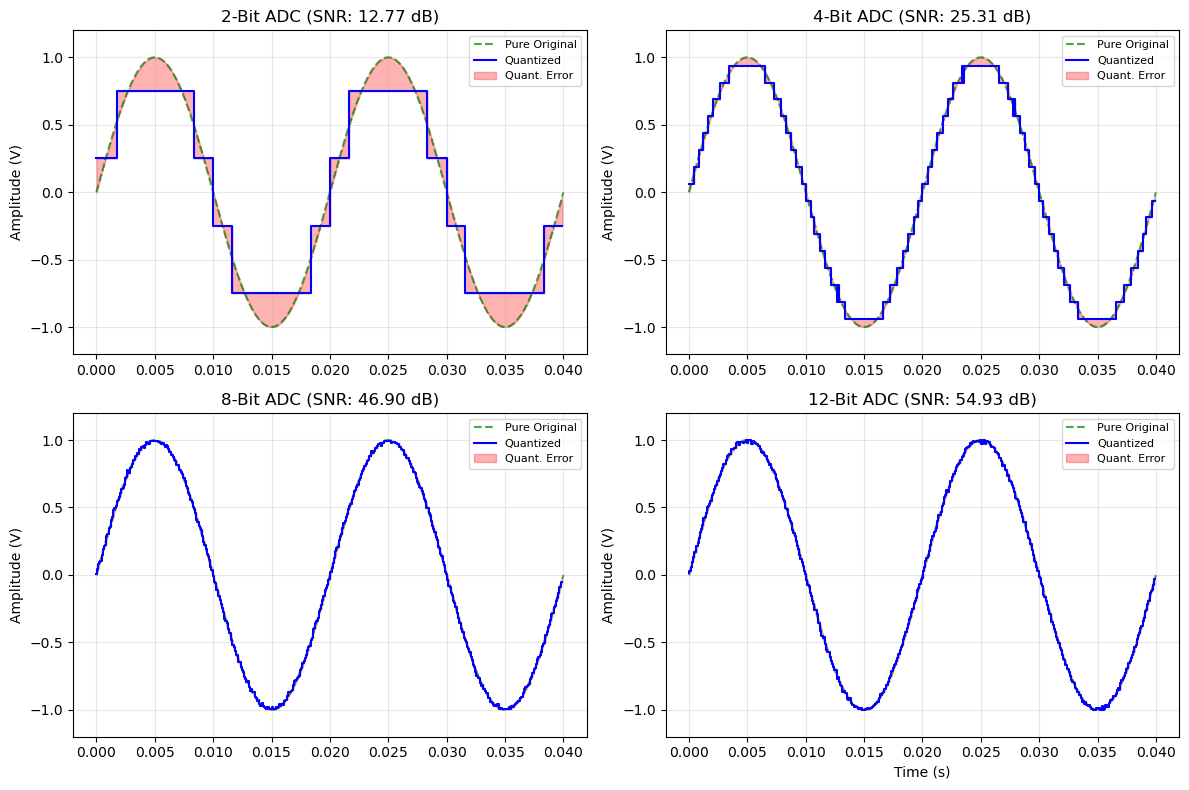

In [ ]:

# High base frequency to simulate a continuous "analog" signal
analog_sampling_freq = 200000  
# ADC actual sampling frequency (10 kHz - well above Nyquist for 50Hz)
adc_sampling_freq = 10000   
signal_freq = 50       
amplitude = 1.0        
min_voltage, max_voltage = -1.0, 1.0

# Time axis and original sine wave (simulating 2 cycles of 50Hz)
analog_time = np.arange(0, 0.04, 1/analog_sampling_freq) 
original_signal = amplitude * np.sin(2 * np.pi * signal_freq * analog_time)

# Downsampling the purely mathematical signal for error calculation
sampling_ratio = int(analog_sampling_freq / adc_sampling_freq)
sampled_original_signal = original_signal[::sampling_ratio]

resolutions = [2, 4, 8, 12]

print("=== SNR COMPARISON: QUANTIZED vs. ORIGINAL SIGNAL ===\n")

plt.figure(figsize=(12, 8))

for i, bits in enumerate(resolutions):
    # Simulate the ADC process. We add a tiny bit of noise (0.01) to keep it realistic.
    # Note: adc_simulation return values updated to English names
    (sampled_time, raw_samples, quantized_signal, quant_noise, 
     binary_output, gray_output, simulated_snr, enob) = adc_simulation(
        original_signal, analog_sampling_freq, adc_sampling_freq, 
        bits, min_voltage, max_voltage, noise_std=0.01
    )
    
    # Theoretical Quantization SNR for a full-scale sine wave: SNR = 6.02N + 1.76
    theoretical_snr = (6.02 * bits) + 1.76
    
    # Calculate Total Error (sampled original vs. quantized staircase)
    total_error = sampled_original_signal - quantized_signal
    original_signal_power = np.mean(sampled_original_signal**2)
    total_error_power = np.mean(total_error**2)
    
    print(f"--- Resolution: {bits} Bits ---")
    print(f"Theoretical Ideal SNR : {theoretical_snr:.2f} dB")
    print(f"Simulated ADC SNR     : {simulated_snr:.2f} dB\n")
    
    plt.subplot(2, 2, i+1)
    # Plot original high-res signal as a reference
    plt.plot(analog_time, original_signal, 'g--', alpha=0.7, label='Pure Original')
    # Plot the discrete "staircase" levels
    plt.step(sampled_time, quantized_signal, where='mid', color='blue', linewidth=1.5, label='Quantized')
    
    # Visualize the quantization error as a filled red area
    plt.fill_between(sampled_time, sampled_original_signal, quantized_signal, 
                     color='red', alpha=0.3, step='mid', label='Quant. Error')
    
    plt.title(f'{bits}-Bit ADC (SNR: {simulated_snr:.2f} dB)')
    plt.ylabel('Amplitude (V)')
    plt.ylim(-1.2, 1.2)
    plt.legend(loc='upper right', fontsize=8)
    plt.grid(True, alpha=0.3)

plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

### DAC para reconstrução do sinal usando Upsampling no ZOH

In [222]:
def simulate_dac(digital_signal_text, bits, v_min, v_max, fs_digital, zoh_factor=100, use_filter=True, gray_input=True):
    """
    Simulates a Digital-to-Analog Converter (DAC) including decoding, 
    Zero-Order Hold (ZOH), and reconstruction filtering.
    
    Parameters:
    -----------
    digital_signal_text : list or numpy.ndarray
        Array of digital signal codes as binary strings or integers.
    bits : int
        ADC/DAC resolution in number of bits (N).
    v_min : float
        Minimum voltage of the output dynamic range (in Volts).
    v_max : float
        Maximum voltage of the output dynamic range (in Volts).
    fs_digital : float
        Sampling rate of the digital signal (in Hz).
    zoh_factor : int, optional
        Upsampling factor for Zero-Order Hold interpolation (default is 100).
    use_filter : bool, optional
        Enable reconstruction low-pass filter (default is True).
    gray_input : bool, optional
        If True, converts Gray code to standard binary; if False, treats input as standard binary (default is True).
    
    Returns:
    --------
    t_digital : numpy.ndarray
        Time axis of the digital samples (at fs_digital rate).
    voltage_signal : numpy.ndarray
        Decoded voltage levels corresponding to each digital code.
    t_analog : numpy.ndarray
        Time axis of the reconstructed analog signal (at fs_digital * zoh_factor).
    zoh_signal : numpy.ndarray
        The zero-order hold staircase output before filtering.
    reconstructed_signal : numpy.ndarray
        Final reconstructed analog signal after low-pass filtering.
    """
    quantization_levels = 2**bits
    fs_analog = fs_digital * zoh_factor

    digital_signal = np.zeros(len(digital_signal_text), dtype=int)
    
    # --- 1. INTELLIGENT DECODING ---
    for i, val in enumerate(digital_signal_text):
        # Convert to integer (handles binary strings or integers)
        int_val = int(val, 2) if isinstance(val, str) else int(val)
        
        if gray_input:
            # Gray Code to Standard Binary conversion algorithm
            mask = int_val >> 1
            bin_int = int_val
            while mask != 0:
                bin_int = bin_int ^ mask
                mask = mask >> 1
            digital_signal[i] = bin_int
        else:
            # If already standard binary, use value directly
            digital_signal[i] = int_val

    # --- 2. QUANTIZATION (Voltage Mapping) ---
    # Calculate the step size (LSB voltage)
    lsb_step = (v_max - v_min) / quantization_levels
    # Map digital codes to voltage levels (centered in the quantization interval)
    voltage_signal = v_min + (digital_signal + 0.5) * lsb_step

    # --- 3. ZERO-ORDER HOLD (ZOH) ---
    # Repeats each sample to simulate the "staircase" effect at a higher analog frequency
    zoh_signal = np.repeat(voltage_signal, zoh_factor)

    # --- 4. RECONSTRUCTION FILTER ---
    if use_filter:
        # Set cutoff at Nyquist frequency (half of the digital sampling rate)
        cutoff_freq = fs_digital / 2 
        # Normalize cutoff frequency relative to the high-res analog frequency
        norm_cutoff = cutoff_freq / (fs_analog / 2) 
        # Design a 6th order Butterworth low-pass filter
        b, a = butter(N=6, Wn=norm_cutoff, btype='low') 
        # Apply zero-phase filtering
        reconstructed_signal = filtfilt(b, a, zoh_signal)
    else:
        reconstructed_signal = zoh_signal

    # Generate time vectors for plotting
    t_digital = np.arange(len(digital_signal)) / fs_digital
    t_analog = np.arange(len(zoh_signal)) / fs_analog

    return t_digital, voltage_signal, t_analog, zoh_signal, reconstructed_signal

Starting A/D conversion...
ADC Completed! SNR: 39.03 dB | ENOB: 6.19 bits

Comparison of first 8 samples:
Standard Binary: ['11111111', '11111111', '11111110', '11111111', '11111111', '11111111', '11111100', '11111100']
Gray Code:       ['10000000', '10000000', '10000001', '10000000', '10000000', '10000000', '10000010', '10000010']

Starting D/A reconstruction...


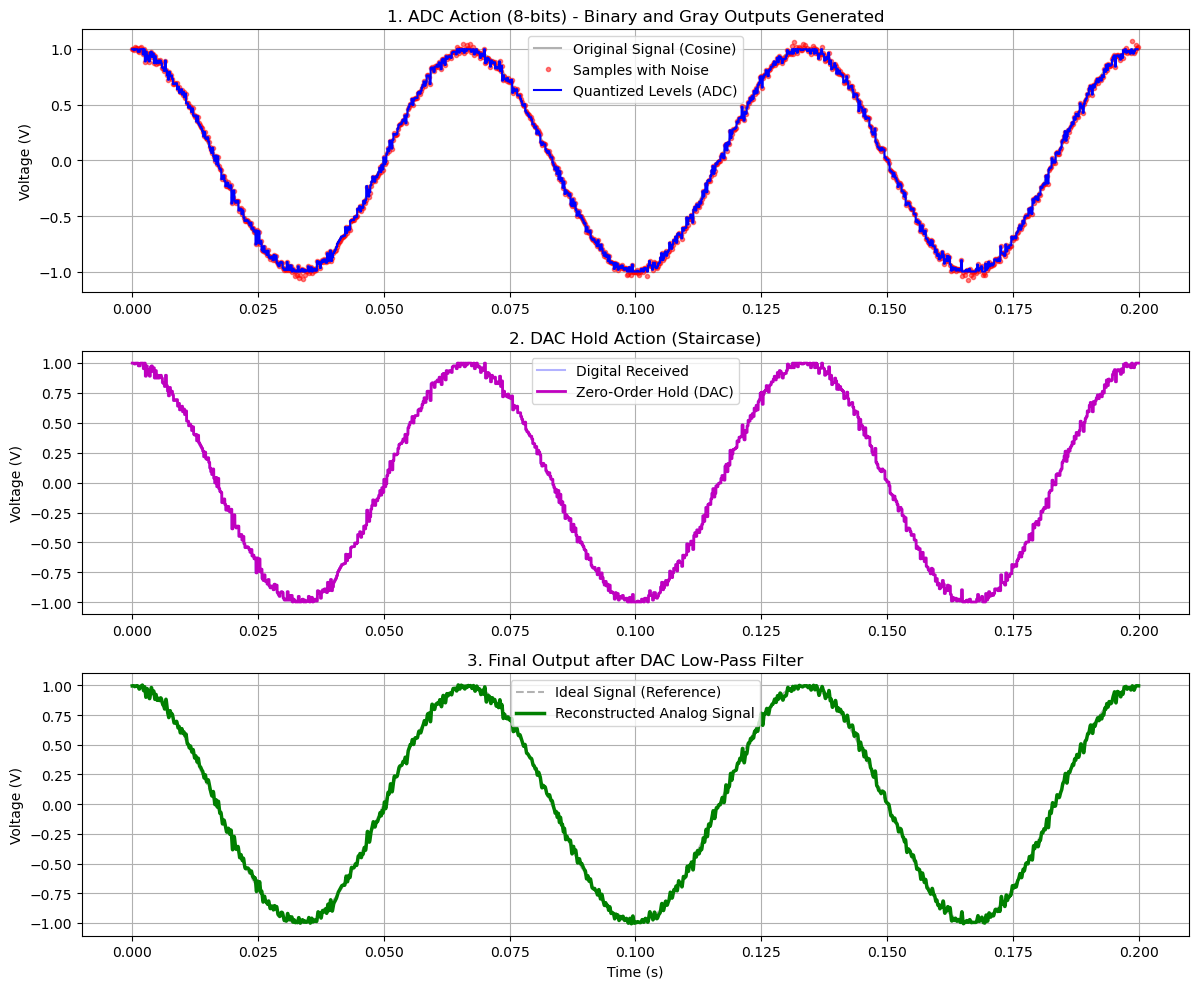

In [223]:
# --- 1. Configuration Parameters ---
ANALOG_SAMPLING_FREQ = 100000  # High resolution for "analog" simulation
ADC_SAMPLING_FREQ = 5000       # Physical hardware sampling rate
SIGNAL_FREQ = 15               # 15 Hz cosine wave
BIT_DEPTH = 8                  # 8-bit resolution
MIN_VOLTAGE = -1.0
MAX_VOLTAGE = 1.0
NOISE_STD = 0.03               # Simulated thermal noise

# --- A. Original Analog Signal (Cosine) ---
original_analog_time = np.arange(0, 0.2, 1/ANALOG_SAMPLING_FREQ)
cosine_signal = 1 * np.cos(2 * np.pi * SIGNAL_FREQ * original_analog_time)

# --- B. ADC Processing ---
print("Starting A/D conversion...")
# Extracting sampled time, raw samples, quantized signal, noise, and digital codes
(sampled_time, sampled_signal, quantized_signal, quantization_noise, 
 binary_out, gray_out, snr, enob) = adc_simulation(
    cosine_signal, ANALOG_SAMPLING_FREQ, ADC_SAMPLING_FREQ, 
    BIT_DEPTH, MIN_VOLTAGE, MAX_VOLTAGE, noise_std=NOISE_STD
)
print(f"ADC Completed! SNR: {snr:.2f} dB | ENOB: {enob:.2f} bits\n")

# Comparing first 8 samples for analysis
print("Comparison of first 8 samples:")
print(f"Standard Binary: {binary_out[:8]}")
print(f"Gray Code:       {gray_out[:8]}\n")

# --- C. DAC Processing (Using Gray Code!) ---
print("Starting D/A reconstruction...")
# Reconstructing from Gray code back to analog voltage
(digital_time, voltage_levels, reconstructed_analog_time, 
 zoh_signal, reconstructed_signal) = simulate_dac(
    gray_out, BIT_DEPTH, MIN_VOLTAGE, MAX_VOLTAGE, 
    fs_digital=ADC_SAMPLING_FREQ, zoh_factor=100, use_filter=True, gray_input=True
)

# --- Plotting Results ---
plt.figure(figsize=(12, 10))

# Plot 1: ADC Action
plt.subplot(3, 1, 1)
plt.plot(original_analog_time, cosine_signal, 'k-', alpha=0.3, label='Original Signal (Cosine)')
plt.plot(sampled_time, sampled_signal, 'r.', alpha=0.5, label='Samples with Noise')
plt.step(sampled_time, quantized_signal, 'b-', where='mid', label='Quantized Levels (ADC)')
plt.title(f'1. ADC Action ({BIT_DEPTH}-bits) - Binary and Gray Outputs Generated')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.legend()

# Plot 2: DAC Staircase (ZOH)
plt.subplot(3, 1, 2)
plt.step(sampled_time, quantized_signal, 'b-', alpha=0.3, where='mid', label='Digital Received')
plt.plot(reconstructed_analog_time, zoh_signal, 'm-', linewidth=2, label='Zero-Order Hold (DAC)')
plt.title('2. DAC Hold Action (Staircase)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.legend()

# Plot 3: Final Reconstructed Output
plt.subplot(3, 1, 3)
plt.plot(original_analog_time, cosine_signal, 'k--', alpha=0.3, label='Ideal Signal (Reference)')
plt.plot(reconstructed_analog_time, reconstructed_signal, 'g-', linewidth=2.5, label='Reconstructed Analog Signal')
plt.title('3. Final Output after DAC Low-Pass Filter')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

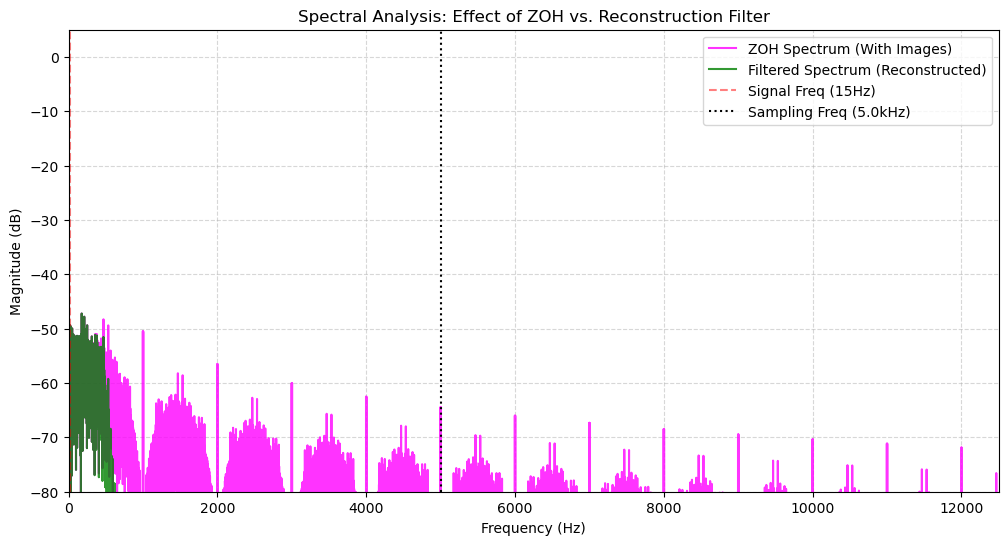

In [225]:
def plot_fft(signal_data, fs, label, color):
    """
    Computes and plots the Magnitude Spectrum of a signal in dB.
    """
    n = len(signal_data)
    
    # Compute the FFT and the frequency bins
    frequencies = np.fft.fftfreq(n, 1/fs)
    fft_values = np.fft.fft(signal_data)
    
    # We only care about the positive half of the spectrum
    half_length = n // 2
    positive_frequencies = frequencies[:half_length]
    
    # Normalize magnitude: Multiply by 2/n to account for the energy split in FFT
    positive_magnitude = np.abs(fft_values[:half_length]) * (2.0 / n)
    
    # Convert to Decibels (dB) for better visualization of harmonics and noise floor
    # Added a tiny offset (1e-10) to avoid log10(0) errors
    magnitude_db = 20 * np.log10(positive_magnitude + 1e-10) 
    
    plt.plot(positive_frequencies, magnitude_db, label=label, color=color, alpha=0.8)

# --- Spectral Analysis Visualization ---
plt.figure(figsize=(12, 6))

# 1. FFT of the Zero-Order Hold (Staircase) signal
# Note: We use ANALOG_SAMPLING_FREQ because the ZOH array was upsampled to this resolution
plot_fft(zoh_signal, ANALOG_SAMPLING_FREQ, 'ZOH Spectrum (With Images)', 'magenta')

# 2. FFT of the Filtered (Reconstructed) signal
plot_fft(reconstructed_signal, ANALOG_SAMPLING_FREQ, 'Filtered Spectrum (Reconstructed)', 'green')

# Graph Settings
plt.title('Spectral Analysis: Effect of ZOH vs. Reconstruction Filter')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')

# Focus on the region of interest (up to 2.5x the ADC sampling frequency)
plt.xlim(0, ADC_SAMPLING_FREQ * 2.5) 
plt.ylim(-80, 5) # Zoomed to see quantization noise and spectral replicas

# Highlight critical frequencies
plt.axvline(SIGNAL_FREQ, color='red', linestyle='--', alpha=0.5, label=f'Signal Freq ({SIGNAL_FREQ}Hz)')
plt.axvline(ADC_SAMPLING_FREQ, color='black', linestyle=':', label=f'Sampling Freq ({ADC_SAMPLING_FREQ/1000}kHz)')

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

--- PROCESSING STANDARD ADC ---
Standard ADC (8 bits) | Real SNR: 32.69 dB | Calculated ENOB: 5.14 bits

--- PROCESSING DYNAMIC ADC (ENOB) ---
Target: ENOB 2 | Theoretical SNR: 13.80 dB | Physical Bits Used: 4
Target: ENOB 4 | Theoretical SNR: 25.84 dB | Physical Bits Used: 6
Target: ENOB 8 | Theoretical SNR: 49.92 dB | Physical Bits Used: 10


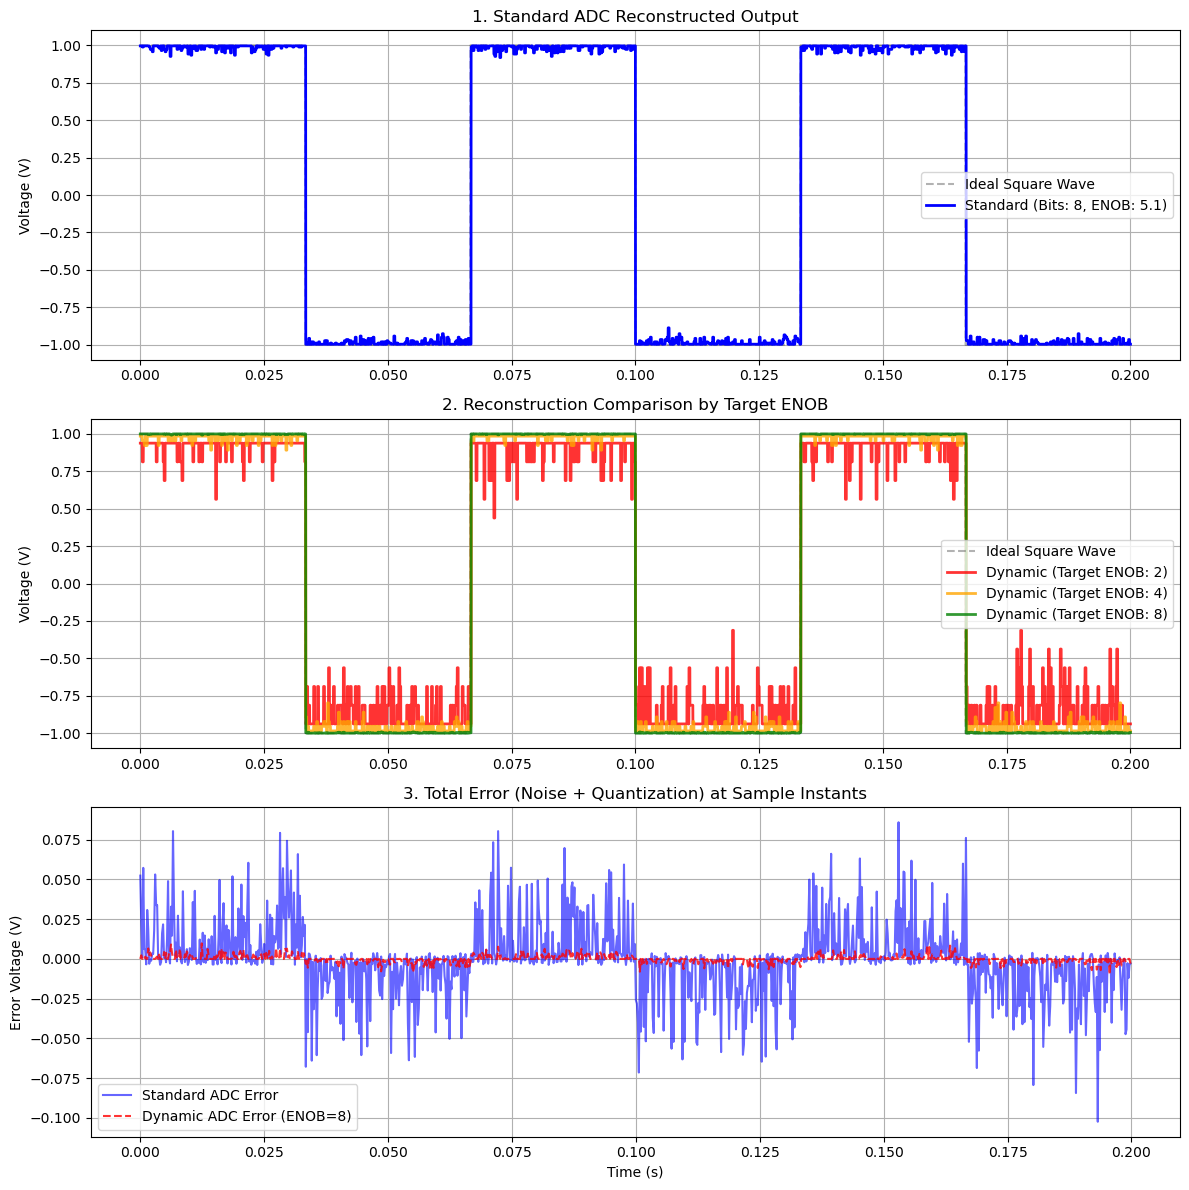

In [ ]:
ANALOG_FS = 100000        # High resolution to simulate "continuous" time
ADC_SAMPLING_FREQ = 5000  # Sampling at 5000 Hz
SIGNAL_FREQ = 15          # 15 Hz square wave frequency
RESOLUTION_BITS = 8       # Physical hardware resolution for the Standard ADC
MIN_VOLTAGE = -1.0
MAX_VOLTAGE = 1.0
SYSTEM_NOISE = 0.03       # System thermal noise
TARGET_ENOB_LIST = [2, 4, 8] # Target ENOBs to test in the dynamic loop

# Generate the Original Analog Signal (Square Wave)
analog_time = np.arange(0, 0.2, 1/ANALOG_FS)
square_signal = 1 * square(2 * np.pi * SIGNAL_FREQ * analog_time)

# Pre-sampling the signal for the Dynamic ADC (which requires pre-sampled inputs)
sampling_step = max(1, int(ANALOG_FS / ADC_SAMPLING_FREQ))
sampled_time = analog_time[::sampling_step]
sampled_signal = square_signal[::sampling_step]

print("--- PROCESSING STANDARD ADC ---")
# Extracting data from the fixed-bit ADC simulation
(std_sampled_time, std_samples, std_quantized, std_quant_noise, 
 std_binary, std_gray, std_snr, std_enob) = adc_simulation(
    square_signal, ANALOG_FS, ADC_SAMPLING_FREQ, RESOLUTION_BITS, MIN_VOLTAGE, MAX_VOLTAGE, noise_std=SYSTEM_NOISE
)
print(f"Standard ADC ({RESOLUTION_BITS} bits) | Real SNR: {std_snr:.2f} dB | Calculated ENOB: {std_enob:.2f} bits")

# DAC Reconstruction for Standard ADC (No Filter to see the ZOH staircase)
(_, _, dac_time, std_zoh_signal, std_reconstructed) = simulate_dac(
    std_gray, RESOLUTION_BITS, MIN_VOLTAGE, MAX_VOLTAGE, 
    fs_digital=ADC_SAMPLING_FREQ, zoh_factor=100, use_filter=False, gray_input=True
)


print("\n--- PROCESSING DYNAMIC ADC (ENOB) ---")
enob_results = {} # Dictionary to store reconstructed signals and errors

for target_enob in TARGET_ENOB_LIST:
    # 1. Process through the Dynamic ADC Model
    (dyn_digital_out, dyn_quant_err, dyn_total_err, step_size, dyn_snr, 
     bits_used, codes, b_str, g_str) = adc_dynamic_model(
        sampled_signal, target_enob, MAX_VOLTAGE, MIN_VOLTAGE
    )
    print(f"Target: ENOB {target_enob} | Theoretical SNR: {dyn_snr:.2f} dB | Physical Bits Used: {bits_used}")
    
    # 2. Process through the DAC
    (_, _, _, _, dyn_reconstructed) = simulate_dac(
        g_str, bits_used, MIN_VOLTAGE, MAX_VOLTAGE, 
        fs_digital=ADC_SAMPLING_FREQ, zoh_factor=100, use_filter=False, gray_input=True
    )
    
    # Store results for plotting
    enob_results[target_enob] = {
        'reconstructed': dyn_reconstructed,
        'total_error': dyn_total_err
    }


plt.figure(figsize=(12, 12))

# Plot 1: Standard ADC Reconstruction
plt.subplot(3, 1, 1)
plt.plot(analog_time, square_signal, 'k--', alpha=0.3, label='Ideal Square Wave')
plt.plot(dac_time, std_reconstructed, 'b-', linewidth=2, label=f'Standard (Bits: {RESOLUTION_BITS}, ENOB: {std_enob:.1f})')
plt.title('1. Standard ADC Reconstructed Output')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.legend()

# Plot 2: Dynamic ADCs Reconstruction (Overlaid)
plt.subplot(3, 1, 2)
plt.plot(analog_time, square_signal, 'k--', alpha=0.3, label='Ideal Square Wave')
colors = ['r', 'orange', 'g']
for i, target_enob in enumerate(TARGET_ENOB_LIST):
    rec_signal = enob_results[target_enob]['reconstructed']
    plt.plot(dac_time, rec_signal, color=colors[i], linewidth=2, alpha=0.8, 
             label=f'Dynamic (Target ENOB: {target_enob})')
plt.title('2. Reconstruction Comparison by Target ENOB')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.legend()

# Plot 3: Total Error Comparison (Noise + Quantization)
plt.subplot(3, 1, 3)
# Standard ADC error (Sampled input vs Quantized result)
standard_total_error = std_samples - std_quantized
plt.plot(sampled_time, standard_total_error, 'b-', alpha=0.6, label='Standard ADC Error')

# Dynamic ADC error for the highest ENOB in the list
selected_enob = TARGET_ENOB_LIST[2]
plt.plot(sampled_time, enob_results[selected_enob]['total_error'], 'r--', alpha=0.8, 
         label=f'Dynamic ADC Error (ENOB={selected_enob})')

plt.title('3. Total Error (Noise + Quantization) at Sample Instants')
plt.xlabel('Time (s)')
plt.ylabel('Error Voltage (V)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

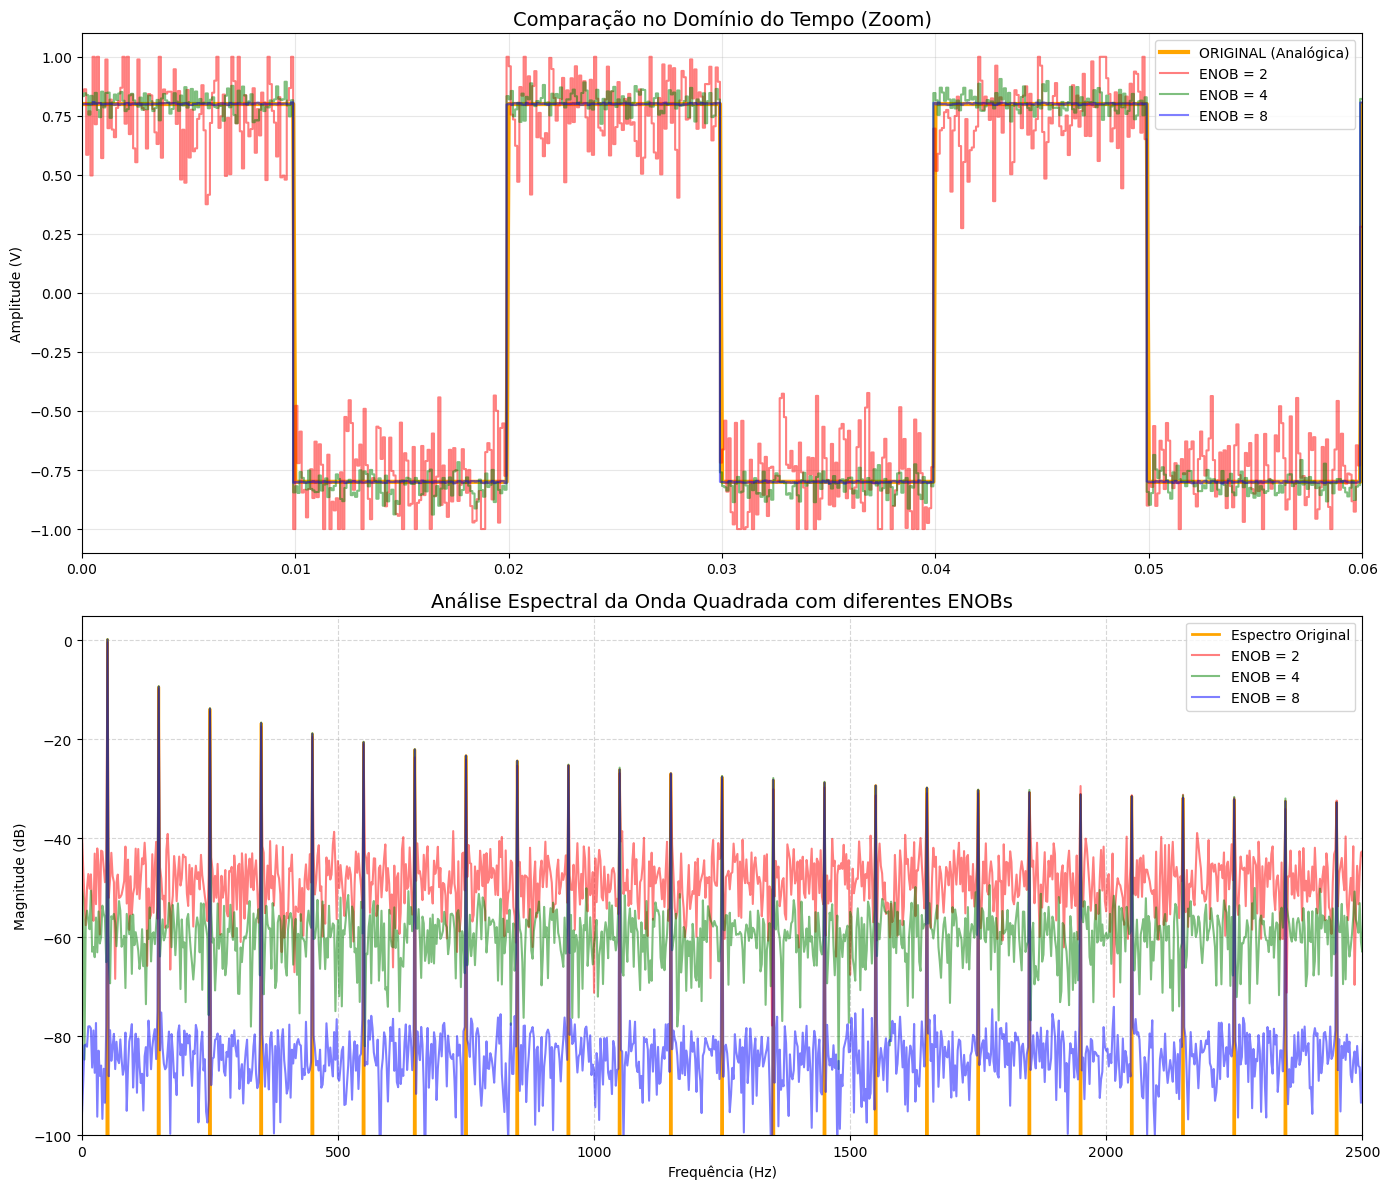

In [246]:
def get_spectrum(signal, fs):
    N = len(signal)
    yf = fft(signal)
    xf = fftfreq(N, 1/fs)[:N//2]
    # Magnitude normalized in dBFS
    mag = 20 * np.log10(np.abs(yf[0:N//2]) / (N/2) + 1e-10)
    return xf, mag

# Parameters
fs = 10000
t = np.arange(0, 0.4, 1/fs)
f_sq = 50
v_max, v_min = 1.0, -1.0
enobs = [2, 4, 8]
analog_in = 0.8 * square(2 * np.pi * f_sq * t)

# Processing
results = {}
for enob in enobs:
    d_out, _, _, _, _, _, _, _, _ = adc_dynamic_model(analog_in, enob, v_max, v_min)
    xf, mag = get_spectrum(d_out, fs)
    results[enob] = (d_out, xf, mag)

xf_orig, mag_orig = get_spectrum(analog_in, fs)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# 1. Time Domain Zoom
ax1.plot(t, analog_in, color='orange', label='ORIGINAL (Analógica)', lw=3)
colors = ['red', 'green', 'blue']
for i, enob in enumerate(enobs):
    ax1.step(t, results[enob][0], color=colors[i], label=f'ENOB = {enob}', alpha=0.5)

ax1.set_title("Comparação no Domínio do Tempo (Zoom)", fontsize=14)
ax1.set_xlim(0, 0.06)
ax1.set_ylabel("Amplitude (V)")
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# 2. Frequency Domain
ax2.plot(xf_orig, mag_orig, color='orange', label='Espectro Original', lw=2)
for i, enob in enumerate(enobs):
    ax2.plot(results[enob][1], results[enob][2], color=colors[i], label=f'ENOB = {enob}', alpha=0.5)

ax2.set_title("Análise Espectral da Onda Quadrada com diferentes ENOBs", fontsize=14)
ax2.set_xlabel("Frequência (Hz)")
ax2.set_ylabel("Magnitude (dB)")
ax2.set_ylim(-100, 5)
ax2.set_xlim(0, 2500)
ax2.grid(True, which='both', linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()